<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Computer_Vision_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import os
import cv2
import sys
import numpy as np

import matplotlib.pyplot as plt


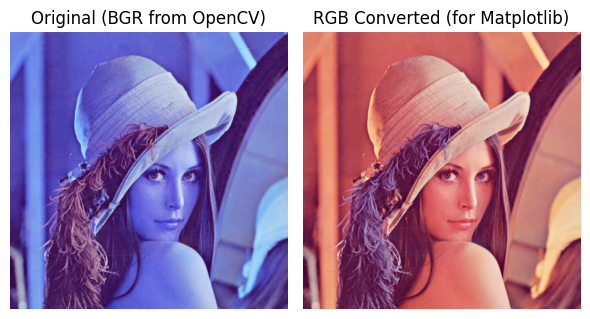

In [ ]:
image_path = '/content/drive/MyDrive/cv_images/Lenna.png'
output_dir = '/content/drive/MyDrive/cv_images/output'

os.makedirs(output_dir, exist_ok=True)

# Read the image in BGR format (default for OpenCV)
input_img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

# Convert the image to RGB format for correct display with Matplotlib
input_img_rgb = cv2.cvtColor(input_img_bgr, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots side by side
plt.figure(figsize=(6, 6))

# First subplot: Original BGR image (will appear distorted if not converted)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(input_img_bgr)
plt.title('Original (BGR from OpenCV)')
plt.axis('off')

# Second subplot: RGB converted image
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(input_img_rgb)
plt.title('RGB Converted (for Matplotlib)')
plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [ ]:
def make_demo_image(h=360, w=480, image_name="demo_image"):
  # Fix: Add a file extension to the output path for cv2.imwrite
  output_path = f"{output_dir}/{image_name}.png"
  demo = np.full((h, w, 3), 110, dtype=np.uint8)

  cv2.rectangle(demo, (40, 40), (200, 200), (0, 0, 255), -1, )
  cv2.circle(demo, (360, 120), 70, (0, 255, 0), -1)
  cv2.rectangle(demo, (260, 240), (440, 330), (255, 0, 0), -1)
  cv2.putText(demo, "DEMO", (150, 320), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255, 255, 255), 3, cv2.LINE_AA)

  cv2.imwrite(output_path, demo)

  return output_path

def load_image(input_path):
  # Fix: Read the image from the path before converting its color
  img = cv2.imread(input_path)
  if img is None:
    # Fix: Raise an Exception object instead of a string
    raise Exception(f"Error: Could not read image from {input_path}")
  return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

array([[[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       ...,

       [[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[110, 110, 110],
        [110, 110, 110],
        [110, 110, 110],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]]], dtype=uint8)
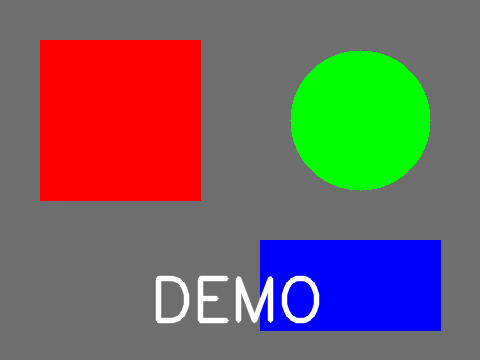

In [ ]:
load_image(make_demo_image())

## Lab 1
Author: Nasif Raihan


In [ ]:
print("python:", sys.executable)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("opencv path:", cv2.__file__)

python: /usr/bin/python3
numpy: 2.1.3
opencv: 4.14.0
opencv path: /usr/local/lib/python3.13/dist-packages/cv2/__init__.py


[ok] Loaded /content/drive/MyDrive/cv_images/Lenna.png
shape: (512, 512, 3) | dtype: uint8


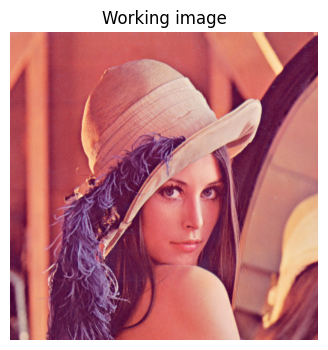

In [ ]:
FOLDER = f"/content/drive/MyDrive/cv_images"
IMG_FILE = "Lenna.png"
img_path = Path(FOLDER) / IMG_FILE

OUT = Path("/content/drive/MyDrive/cv_images/output")
OUT.mkdir(exist_ok=True)

def load_color(path):
    """Load an image in color (BGR). Returns None on failure (see doc 1.2.1)."""
    return cv2.imread(str(path), cv2.IMREAD_COLOR)

def make_demo_image(h=360, w=480):
    """Synthetic fallback so the labs run even without your own image."""
    demo = np.full((h, w, 3), 30, dtype=np.uint8) # dark background
    cv2.rectangle(demo, (40, 40), (200, 200), (0, 0, 255), -1) # red block (BGR
    cv2.circle(demo, (360, 120), 70, (0, 255, 0), -1) # green circle
    cv2.rectangle(demo, (260, 240), (440, 330), (255, 0, 0), -1) # blue block
    cv2.putText(demo, "DEMO", (150, 320), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255, 255, 255), 3, cv2.LINE_AA)
    return demo

# Always check for None after imread, then fall back to the demo image
img = load_color(img_path)
if img is None:
    print(f"[warn] Could not load {img_path}.")
    print(" Using a synthetic demo image. Edit FOLDER/IMG_FILE to use your own")
    img = make_demo_image()
else:
    print(f"[ok] Loaded {img_path}")
    print("shape:", img.shape, "| dtype:", img.dtype)

def show(img_bgr, title="", cmap=None):
    """Display a BGR (color) or single-channel (grayscale) image correctly."""
    plt.figure(figsize=(4, 4))
    if img_bgr.ndim == 2: # grayscale / single channel
        plt.imshow(img_bgr, cmap=cmap or "gray", vmin=0, vmax=255)

    else: # color: BGR -> RGB before display
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()

show(img, "Working image")

# Task 1 — Pixel Explorer
**Goal:** build confidence reading and interpreting pixel values

## Step 1: Confirm the image is loaded correctly

In [ ]:
print("shape:", img.shape)
print("dtype:", img.dtype)

shape: (512, 512, 3)
dtype: uint8


## Step 2: Extract the image's dimensions

In [ ]:
H, W = img.shape[:2]
print(f"{H=}, {W=}")

H=512, W=512


## Step 3: Create a reproducible random number generator

In [ ]:
rng = np.random.default_rng(0)
print(f"{rng=}")

rng=Generator(PCG64) at 0x7EDE1E969460


## Step 4: Generate 10 random x-coordinates and 10 random y-coordinates

In [ ]:
n = 10
xs = rng.integers(0, W, size=n)
ys = rng.integers(0, H, size=n)

print(f"{xs=}\n{ys=}")

xs=array([435, 326, 261, 138, 157,  20,  38,   8,  89, 416])
ys=array([332, 467, 257, 310, 497, 373, 323, 278, 286, 478])


## Step 5: Define the helper function (but don't run it yet)

In [ ]:
def describe(b, g, r):
    """Very rough intuition: which channel dominates?"""

    channels = {"blue": b, "green": g, "red": r}
    strongest = max(channels, key=channels.get)

    if max(b, g, r) - min(b, g, r) < 20:
        return "near-gray (channels are close)"

    return f"looks {strongest}-ish"

## Step 6: Print the table header

## Step 7: Loop through the 10 coordinate pairs, one at a time

In [ ]:
print("\n (x, y) -> ( B, G, R) interpretation")
for x, y in zip(xs, ys):
    b, g, r = img[y, x]

    print(f"({x:4d},{y:4d}) -> ({b:3d}, {g:3d}, {r:3d}) {describe(int(b), int(g), int(r))}")


 (x, y) -> ( B, G, R) interpretation
( 435, 332) -> (123, 124, 195) looks red-ish
( 326, 467) -> (131, 148, 228) looks red-ish
( 261, 257) -> ( 63,  33, 124) looks red-ish
( 138, 310) -> ( 75,  29,  99) looks red-ish
( 157, 497) -> (138,  91, 142) looks red-ish
(  20, 373) -> ( 86,  69, 168) looks red-ish
(  38, 323) -> (115, 142, 233) looks red-ish
(   8, 278) -> ( 73,  63, 172) looks red-ish
(  89, 286) -> ( 91,  73, 188) looks red-ish
( 416, 478) -> ( 68,  21,  81) looks red-ish


# Task 2 — ROI Practice

**Goal:** become fluent with slicing

## Step 1: Get the image dimensions

In [ ]:
H, W = img.shape[:2]
print(f"{H=}, {W=}")

H=512, W=512


## Step 2: Define three ROIs as percentages of the image

In [ ]:
rois = {
    "small": (int(0.48*W), int(0.47*H), int(0.58*W), int(0.55*H)),
    "medium": (int(0.45*W), int(0.35*H), int(0.70*W), int(0.75*H)),
    "large": (int(0.2*W), int(0.08*H), int(0.80*W), int(0.80*H)),
}

## Step 3: Make a safe copy of the image to draw on

## Step 4: Loop through the three ROIs, one at a time

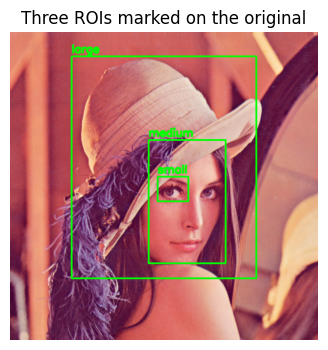

Saved: ['roi_small.png', 'roi_medium.png', 'roi_large.png']


In [ ]:
marked = img.copy() # keep the original intact
for name, (x1, y1, x2, y2) in rois.items():
    patch = img[y1:y2, x1:x2].copy() # .copy() -> independent regio
    cv2.imwrite(str(OUT / f"roi_{name}.png"), patch)
    cv2.rectangle(marked, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(marked, name, (x1, max(0, y1 - 6)),
    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

cv2.imwrite(str(OUT / f"roi_marked.png"), marked)
show(marked, "Three ROIs marked on the original")
print("Saved:", [f"roi_{n}.png" for n in rois])

## Task 3 — Channel Visualization

In [ ]:
b, g, r = cv2.split(img)
# Save each channel as a grayscale image
cv2.imwrite(str(OUT / "channel_B.png"), b)
cv2.imwrite(str(OUT / "channel_G.png"), g)
cv2.imwrite(str(OUT / "channel_R.png"), r)

# "Only one color" images: keep one channel, zero the other two
zeros = np.zeros_like(b)
only_blue = cv2.merge([b, zeros, zeros]) # order is (B, G, R)
only_green = cv2.merge([zeros, g, zeros])
only_red = cv2.merge([zeros, zeros, r])

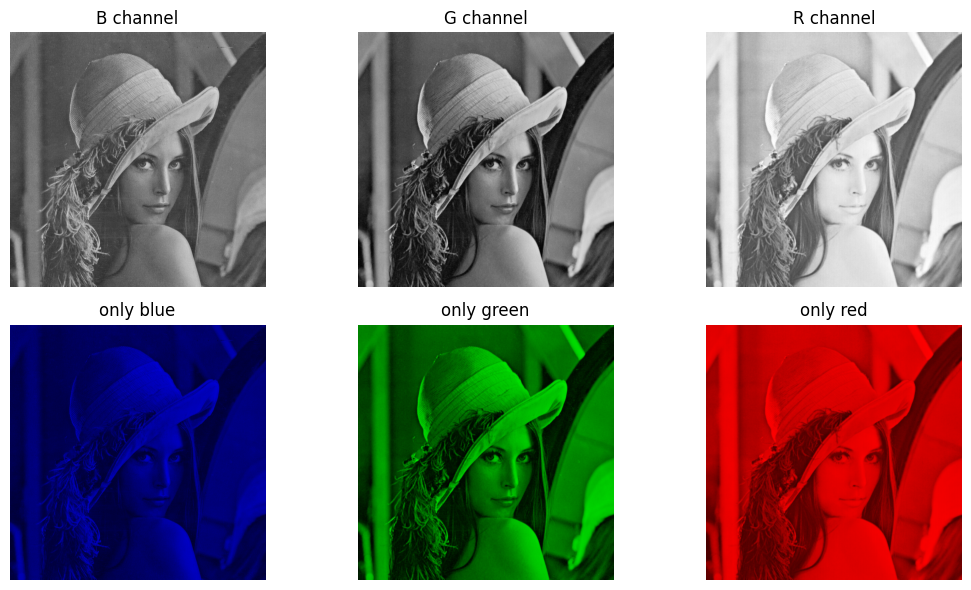

In [ ]:
for name, im in [("only_blue", only_blue), ("only_green", only_green), ("only_red", only_red)]:
    cv2.imwrite(str(OUT / f"{name}.png"), im)


fig, ax = plt.subplots(2, 3, figsize=(11, 6))
ax[0,0].imshow(b, cmap="gray", vmin=0, vmax=255); ax[0,0].set_title("B channel")
ax[0,1].imshow(g, cmap="gray", vmin=0, vmax=255); ax[0,1].set_title("G channel")
ax[0,2].imshow(r, cmap="gray", vmin=0, vmax=255); ax[0,2].set_title("R channel")
ax[1,0].imshow(cv2.cvtColor(only_blue, cv2.COLOR_BGR2RGB)); ax[1,0].set_title("only blue")
ax[1,1].imshow(cv2.cvtColor(only_green, cv2.COLOR_BGR2RGB)); ax[1,1].set_title("only green")
ax[1,2].imshow(cv2.cvtColor(only_red, cv2.COLOR_BGR2RGB)); ax[1,2].set_title("only red")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

# Task 4 — Annotation Toolkit

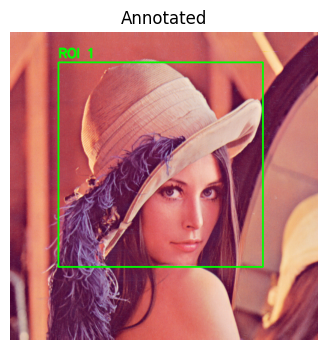

Saved: /content/drive/MyDrive/cv_images/output/annotated.png


In [ ]:
def annotate(image_bgr, x1, y1, x2, y2, label="object", color=(0, 255, 0), thickness=2):
    """Return a copy of image_bgr with a labeled rectangle drawn on it."""
    out = image_bgr.copy()
    cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(out, label, (x1, max(0, y1 - 8)),
    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
    return out

# Example with fixed coordinates (always runs)
annotated = annotate(img, 80, 50, 420, 390, label="ROI 1")
show(annotated, "Annotated")
cv2.imwrite(str(OUT / "annotated.png"), annotated)
print("Saved:", OUT / "annotated.png")

Enter x1 y1 x2 y2 (e.g. 220 240 370 380): 220 240 370 380


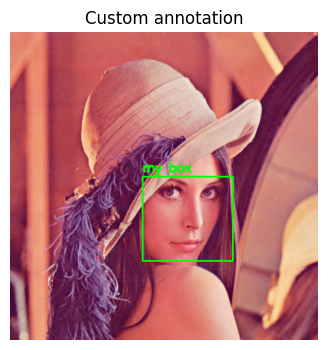

Saved: /content/drive/MyDrive/cv_images/output/annotated_user.png


In [ ]:
try:
    raw = input("Enter x1 y1 x2 y2 (e.g. 220 240 370 380): ").strip()
    x1, y1, x2, y2 = map(int, raw.split())
    user_annot = annotate(img, x1, y1, x2, y2, label="my box")
    show(user_annot, "Custom annotation")
    cv2.imwrite(str(OUT / "annotated_user.png"), user_annot)
    print("Saved:", OUT / "annotated_user.png")
except Exception as e:
    print("Skipped interactive input:", e)